In [3]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/wordsforthewise/lending-club/rejected_2007_to_2018Q4.csv.gz
/kaggle/input/datasets/wordsforthewise/lending-club/accepted_2007_to_2018Q4.csv.gz
/kaggle/input/datasets/wordsforthewise/lending-club/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv
/kaggle/input/datasets/wordsforthewise/lending-club/rejected_2007_to_2018q4.csv/rejected_2007_to_2018Q4.csv


In [4]:
import pandas as pd

accepted_path = "/kaggle/input/datasets/wordsforthewise/lending-club/accepted_2007_to_2018Q4.csv.gz"

df = pd.read_csv(accepted_path, compression="gzip", low_memory=False)

print("Dataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully
Rows: 2260701
Columns: 151


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Check all column names
print("Column names:")
print(df.columns.tolist())

# Check target variable values
print("\nLoan status values:")
print(df["loan_status"].value_counts(dropna=False))

Column names:
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'ac

In [6]:
# Keep only final loan outcomes for supervised learning

final_statuses = [
    "Fully Paid",
    "Charged Off",
    "Default",
    "Does not meet the credit policy. Status:Fully Paid",
    "Does not meet the credit policy. Status:Charged Off"
]

df_model = df[df["loan_status"].isin(final_statuses)].copy()

# Create target variable
# 0 = good loan / fully paid
# 1 = bad loan / default or charged off

df_model["default_target"] = df_model["loan_status"].apply(
    lambda x: 1 if x in [
        "Charged Off",
        "Default",
        "Does not meet the credit policy. Status:Charged Off"
    ] else 0
)

print("Filtered dataset shape:", df_model.shape)

print("\nLoan status after filtering:")
print(df_model["loan_status"].value_counts())

print("\nTarget variable distribution:")
print(df_model["default_target"].value_counts())
print(df_model["default_target"].value_counts(normalize=True) * 100)

Filtered dataset shape: (1348099, 152)

Loan status after filtering:
loan_status
Fully Paid                                             1076751
Charged Off                                             268559
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

Target variable distribution:
default_target
0    1078739
1     269360
Name: count, dtype: int64
default_target
0    80.019272
1    19.980728
Name: proportion, dtype: float64


In [7]:
# Select useful pre-loan / application-time features for the first model

selected_features = [
    "loan_amnt",
    "term",
    "int_rate",
    "installment",
    "grade",
    "sub_grade",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "purpose",
    "addr_state",
    "dti",
    "delinq_2yrs",
    "earliest_cr_line",
    "fico_range_low",
    "fico_range_high",
    "inq_last_6mths",
    "mths_since_last_delinq",
    "mths_since_last_record",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "initial_list_status",
    "application_type",
    "mort_acc",
    "pub_rec_bankruptcies"
]

model_data = df_model[selected_features + ["default_target"]].copy()

print("Model dataset shape:", model_data.shape)

print("\nFirst 5 rows:")
display(model_data.head())

print("\nMissing values percentage:")
missing_percent = model_data.isnull().mean().sort_values(ascending=False) * 100
print(missing_percent)

Model dataset shape: (1348099, 30)

First 5 rows:


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,default_target
0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,...,7.0,0.0,2765.0,29.7,13.0,w,Individual,1.0,0.0,0
1,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,...,22.0,0.0,21470.0,19.2,38.0,w,Individual,4.0,0.0,0
2,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,...,6.0,0.0,7869.0,56.2,18.0,w,Joint App,5.0,0.0,0
4,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Source Verified,...,12.0,0.0,21929.0,64.5,35.0,w,Individual,6.0,0.0,0
5,11950.0,36 months,13.44,405.18,C,C3,4 years,RENT,34000.0,Source Verified,...,5.0,0.0,8822.0,68.4,6.0,w,Individual,0.0,0.0,0



Missing values percentage:
mths_since_last_record    82.981665
mths_since_last_delinq    50.438432
emp_length                 5.826723
mort_acc                   3.711152
pub_rec_bankruptcies       0.101254
revol_util                 0.066538
dti                        0.027743
inq_last_6mths             0.002225
earliest_cr_line           0.002151
open_acc                   0.002151
delinq_2yrs                0.002151
pub_rec                    0.002151
total_acc                  0.002151
annual_inc                 0.000297
purpose                    0.000000
addr_state                 0.000000
home_ownership             0.000000
verification_status        0.000000
int_rate                   0.000000
installment                0.000000
grade                      0.000000
sub_grade                  0.000000
term                       0.000000
loan_amnt                  0.000000
fico_range_low             0.000000
fico_range_high            0.000000
initial_list_status        0.000000


In [8]:
# Create missing-data indicator variables

missing_indicator_cols = [
    "mths_since_last_record",
    "mths_since_last_delinq",
    "emp_length",
    "mort_acc",
    "pub_rec_bankruptcies",
    "revol_util",
    "dti"
]

for col in missing_indicator_cols:
    model_data[col + "_missing"] = model_data[col].isnull().astype(int)

print("Missing indicator columns created successfully")

print("\nNew dataset shape:")
print(model_data.shape)

print("\nMissing indicator summary:")
missing_summary = model_data[[col + "_missing" for col in missing_indicator_cols]].mean().sort_values(ascending=False) * 100
print(missing_summary)

Missing indicator columns created successfully

New dataset shape:
(1348099, 37)

Missing indicator summary:
mths_since_last_record_missing    82.981665
mths_since_last_delinq_missing    50.438432
emp_length_missing                 5.826723
mort_acc_missing                   3.711152
pub_rec_bankruptcies_missing       0.101254
revol_util_missing                 0.066538
dti_missing                        0.027743
dtype: float64


In [9]:
# Clean selected columns and create useful numeric features

import numpy as np
import pandas as pd

# Clean term: "36 months" -> 36
model_data["term"] = model_data["term"].astype(str).str.extract("(\d+)").astype(float)

# Clean employment length
emp_map = {
    "< 1 year": 0,
    "1 year": 1,
    "2 years": 2,
    "3 years": 3,
    "4 years": 4,
    "5 years": 5,
    "6 years": 6,
    "7 years": 7,
    "8 years": 8,
    "9 years": 9,
    "10+ years": 10
}

model_data["emp_length"] = model_data["emp_length"].map(emp_map)

# Convert earliest credit line to date
model_data["earliest_cr_line"] = pd.to_datetime(
    model_data["earliest_cr_line"], 
    errors="coerce"
)

# Create credit history length in years using 2018 as reference year
model_data["credit_history_years"] = 2018 - model_data["earliest_cr_line"].dt.year

# Drop original date column after creating numeric feature
model_data = model_data.drop(columns=["earliest_cr_line"])

print("Data cleaning completed successfully")
print("Updated dataset shape:", model_data.shape)

display(model_data[["term", "emp_length", "credit_history_years"]].head())

<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_58/1380572323.py:7: SyntaxWarning: invalid escape sequence '\d'
  model_data["term"] = model_data["term"].astype(str).str.extract("(\d+)").astype(float)
/tmp/ipykernel_58/1380572323.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  model_data["earliest_cr_line"] = pd.to_datetime(


Data cleaning completed successfully
Updated dataset shape: (1348099, 37)


,term,emp_length,credit_history_years
0,36.0,10.0,15.0
1,36.0,10.0,19.0
2,60.0,10.0,18.0
4,60.0,3.0,20.0
5,36.0,4.0,31.0


In [10]:
# Separate input features and target variable

X = model_data.drop(columns=["default_target"])
y = model_data["default_target"]

print("Feature dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

Feature dataset shape: (1348099, 36)
Target dataset shape: (1348099,)

Target distribution:
default_target
0    1078739
1     269360
Name: count, dtype: int64
default_target
0    80.019272
1    19.980728
Name: proportion, dtype: float64


In [11]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
# stratify=y keeps the same default/non-default ratio in both sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

X_train shape: (1078479, 36)
X_test shape: (269620, 36)
y_train shape: (1078479,)
y_test shape: (269620,)

Training target distribution:
default_target
0    80.019268
1    19.980732
Name: proportion, dtype: float64

Testing target distribution:
default_target
0    80.019286
1    19.980714
Name: proportion, dtype: float64


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Identify numeric and categorical columns
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nCategorical features:")
print(categorical_features)

# Numeric preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Full preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("\nPreprocessing pipeline created successfully")

Number of numeric features: 28
Number of categorical features: 8

Categorical features:
['grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'initial_list_status', 'application_type']

Preprocessing pipeline created successfully


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Create baseline Logistic Regression pipeline
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=-1))
])

# Train the model
logistic_model.fit(X_train, y_train)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test)
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

# Evaluate model
print("Logistic Regression Baseline Results")
print("Accuracy:", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall:", recall_score(y_test, y_pred_logistic))
print("F1 Score:", f1_score(y_test, y_pred_logistic))
print("ROC AUC:", roc_auc_score(y_test, y_prob_logistic))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Baseline Results
Accuracy: 0.670169126919368
Precision: 0.32409758251462634
Recall: 0.5994950994950995
F1 Score: 0.42073722813165626
ROC AUC: 0.7017138020522177


In [14]:
from sklearn.preprocessing import StandardScaler

# Improved numeric preprocessing with scaling
numeric_transformer_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing remains the same
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Updated preprocessing pipeline
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_scaled, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Create improved Logistic Regression pipeline
logistic_model_scaled = Pipeline(steps=[
    ("preprocessor", preprocessor_scaled),
    ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced", n_jobs=-1))
])

# Train the improved model
logistic_model_scaled.fit(X_train, y_train)

# Make predictions
y_pred_logistic_scaled = logistic_model_scaled.predict(X_test)
y_prob_logistic_scaled = logistic_model_scaled.predict_proba(X_test)[:, 1]

# Evaluate improved model
print("Improved Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_logistic_scaled))
print("Precision:", precision_score(y_test, y_pred_logistic_scaled))
print("Recall:", recall_score(y_test, y_pred_logistic_scaled))
print("F1 Score:", f1_score(y_test, y_pred_logistic_scaled))
print("ROC AUC:", roc_auc_score(y_test, y_prob_logistic_scaled))

Improved Logistic Regression Results
Accuracy: 0.6447110748460797
Precision: 0.3178092431788747
Recall: 0.6787013662013662
F1 Score: 0.43290571220525814
ROC AUC: 0.7163691675387612


In [15]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest pipeline
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

# Train the model
random_forest_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

# Evaluate model
print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest Results
Accuracy: 0.6317409687708627
Precision: 0.3100110434375209
Recall: 0.6878341253341254
F1 Score: 0.4273933102652826
ROC AUC: 0.7119376436183544


In [16]:
# Create model comparison table

results_table = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Improved Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_logistic_scaled),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_logistic_scaled),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_logistic_scaled),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_logistic_scaled),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_prob_logistic),
        roc_auc_score(y_test, y_prob_logistic_scaled),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results_table

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.670169,0.324098,0.599495,0.420737,0.701714
1,Improved Logistic Regression,0.644711,0.317809,0.678701,0.432906,0.716369
2,Random Forest,0.631741,0.310011,0.687834,0.427393,0.711938


In [17]:
# Save model comparison table as CSV

results_table.to_csv("/kaggle/working/model_comparison_results.csv", index=False)

print("Model comparison table saved successfully")
print("File saved at: /kaggle/working/model_comparison_results.csv")

Model comparison table saved successfully
File saved at: /kaggle/working/model_comparison_results.csv


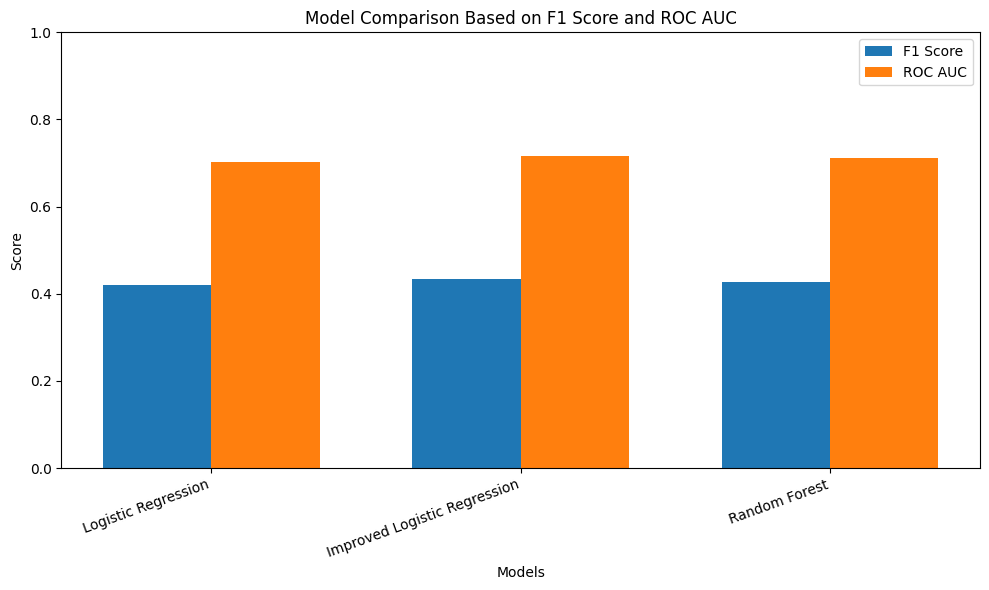

Model comparison figure saved successfully
File saved at: /kaggle/working/model_comparison_figure.pdf


In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Create model comparison figure using ROC AUC and F1 Score

comparison_plot_data = results_table[["Model", "F1 Score", "ROC AUC"]].copy()

x = np.arange(len(comparison_plot_data["Model"]))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, comparison_plot_data["F1 Score"], width, label="F1 Score")
plt.bar(x + width/2, comparison_plot_data["ROC AUC"], width, label="ROC AUC")

plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Model Comparison Based on F1 Score and ROC AUC")
plt.xticks(x, comparison_plot_data["Model"], rotation=20, ha="right")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

plt.savefig("/kaggle/working/model_comparison_figure.pdf", format="pdf", bbox_inches="tight")
plt.show()

print("Model comparison figure saved successfully")
print("File saved at: /kaggle/working/model_comparison_figure.pdf")

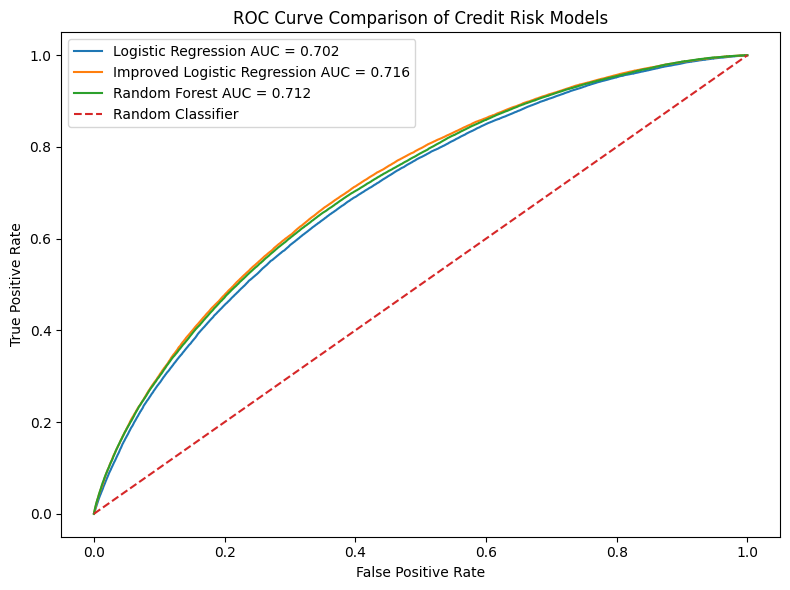

ROC curve figure saved successfully
File saved at: /kaggle/working/roc_curve_comparison.pdf


In [19]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curves
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_logistic)
roc_auc_log = auc(fpr_log, tpr_log)

fpr_log_scaled, tpr_log_scaled, _ = roc_curve(y_test, y_prob_logistic_scaled)
roc_auc_log_scaled = auc(fpr_log_scaled, tpr_log_scaled)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression AUC = {roc_auc_log:.3f}")
plt.plot(fpr_log_scaled, tpr_log_scaled, label=f"Improved Logistic Regression AUC = {roc_auc_log_scaled:.3f}")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {roc_auc_rf:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Credit Risk Models")
plt.legend()
plt.tight_layout()

plt.savefig("/kaggle/working/roc_curve_comparison.pdf", format="pdf", bbox_inches="tight")
plt.show()

print("ROC curve figure saved successfully")
print("File saved at: /kaggle/working/roc_curve_comparison.pdf")

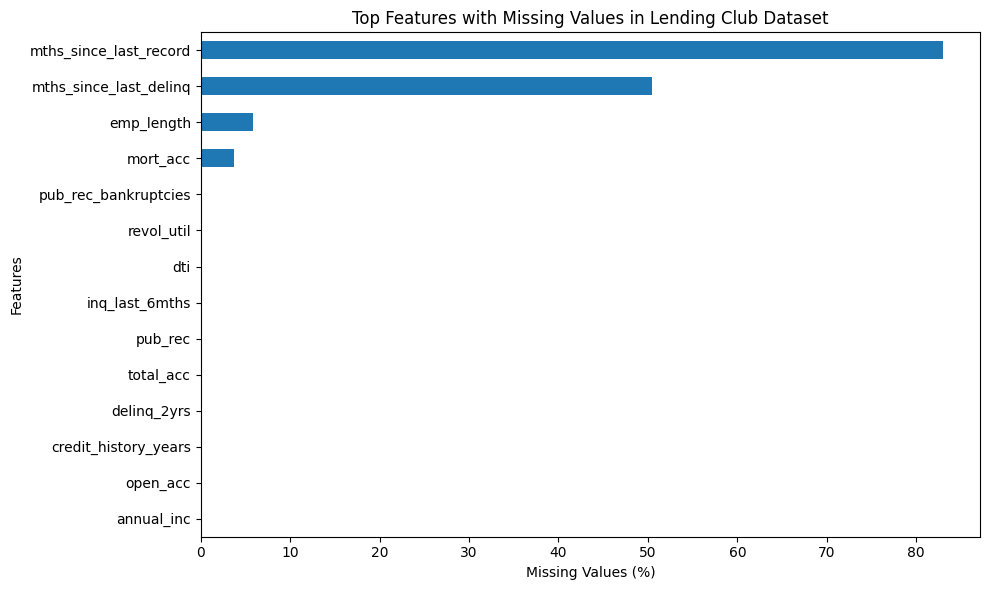

Missing-data analysis figure saved successfully
File saved at: /kaggle/working/missing_data_analysis.pdf


In [20]:
import matplotlib.pyplot as plt

# Create missing-data percentage figure

missing_percent_plot = model_data.isnull().mean().sort_values(ascending=False) * 100
missing_percent_plot = missing_percent_plot[missing_percent_plot > 0].head(15)

plt.figure(figsize=(10, 6))
missing_percent_plot.sort_values().plot(kind="barh")

plt.xlabel("Missing Values (%)")
plt.ylabel("Features")
plt.title("Top Features with Missing Values in Lending Club Dataset")
plt.tight_layout()

plt.savefig("/kaggle/working/missing_data_analysis.pdf", format="pdf", bbox_inches="tight")
plt.show()

print("Missing-data analysis figure saved successfully")
print("File saved at: /kaggle/working/missing_data_analysis.pdf")

<Figure size 700x600 with 0 Axes>

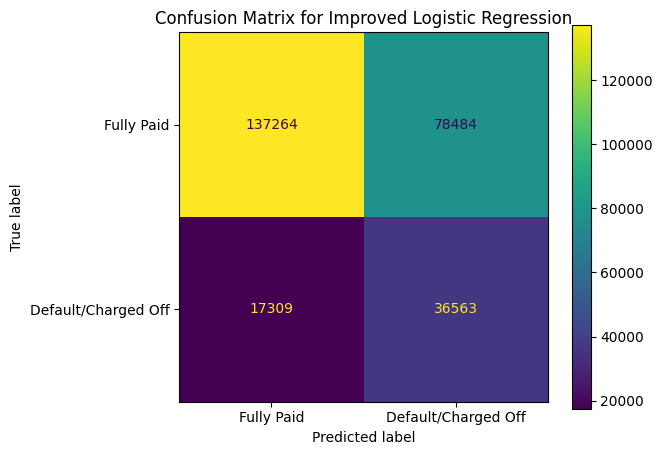

Confusion matrix figure saved successfully
File saved at: /kaggle/working/confusion_matrix_best_model.pdf
[[137264  78484]
 [ 17309  36563]]


In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion matrix for best model: Improved Logistic Regression

cm = confusion_matrix(y_test, y_pred_logistic_scaled)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fully Paid", "Default/Charged Off"]
)

plt.figure(figsize=(7, 6))
disp.plot(values_format="d")
plt.title("Confusion Matrix for Improved Logistic Regression")
plt.tight_layout()

plt.savefig("/kaggle/working/confusion_matrix_best_model.pdf", format="pdf", bbox_inches="tight")
plt.show()

print("Confusion matrix figure saved successfully")
print("File saved at: /kaggle/working/confusion_matrix_best_model.pdf")
print(cm)

In [22]:
# Human-in-the-loop uncertainty prioritisation

review_results = pd.DataFrame({
    "actual_default": y_test.values,
    "predicted_default": y_pred_logistic_scaled,
    "default_probability": y_prob_logistic_scaled
})

# Uncertainty is highest when probability is close to 0.50
review_results["uncertainty_score"] = 1 - abs(review_results["default_probability"] - 0.5) * 2

# Create review priority groups
def assign_review_group(prob):
    if prob >= 0.70:
        return "High Risk - Manual Review"
    elif prob <= 0.30:
        return "Low Risk - Auto Decision"
    else:
        return "Uncertain - Human Review Priority"

review_results["review_group"] = review_results["default_probability"].apply(assign_review_group)

print("Review prioritisation completed successfully")

print("\nReview group counts:")
print(review_results["review_group"].value_counts())

print("\nReview group percentages:")
print(review_results["review_group"].value_counts(normalize=True) * 100)

print("\nDefault rate by review group:")
print(review_results.groupby("review_group")["actual_default"].mean() * 100)

display(review_results.head())

Review prioritisation completed successfully

Review group counts:
review_group
Uncertain - Human Review Priority    178972
Low Risk - Auto Decision              61152
High Risk - Manual Review             29496
Name: count, dtype: int64

Review group percentages:
review_group
Uncertain - Human Review Priority    66.379349
Low Risk - Auto Decision             22.680810
High Risk - Manual Review            10.939841
Name: proportion, dtype: float64

Default rate by review group:
review_group
High Risk - Manual Review            45.172227
Low Risk - Auto Decision              6.011251
Uncertain - Human Review Priority    20.602105
Name: actual_default, dtype: float64


,actual_default,predicted_default,default_probability,uncertainty_score,review_group
0,1,1,0.627073,0.745853,Uncertain - Human Review Priority
1,0,0,0.327821,0.655642,Uncertain - Human Review Priority
2,0,1,0.534009,0.931982,Uncertain - Human Review Priority
3,0,0,0.278602,0.557204,Low Risk - Auto Decision
4,0,0,0.374296,0.748592,Uncertain - Human Review Priority


In [23]:
# Save human-in-the-loop review prioritisation results

review_results.to_csv("/kaggle/working/human_review_prioritisation_results.csv", index=False)

print("Human review prioritisation table saved successfully")
print("File saved at: /kaggle/working/human_review_prioritisation_results.csv")

Human review prioritisation table saved successfully
File saved at: /kaggle/working/human_review_prioritisation_results.csv


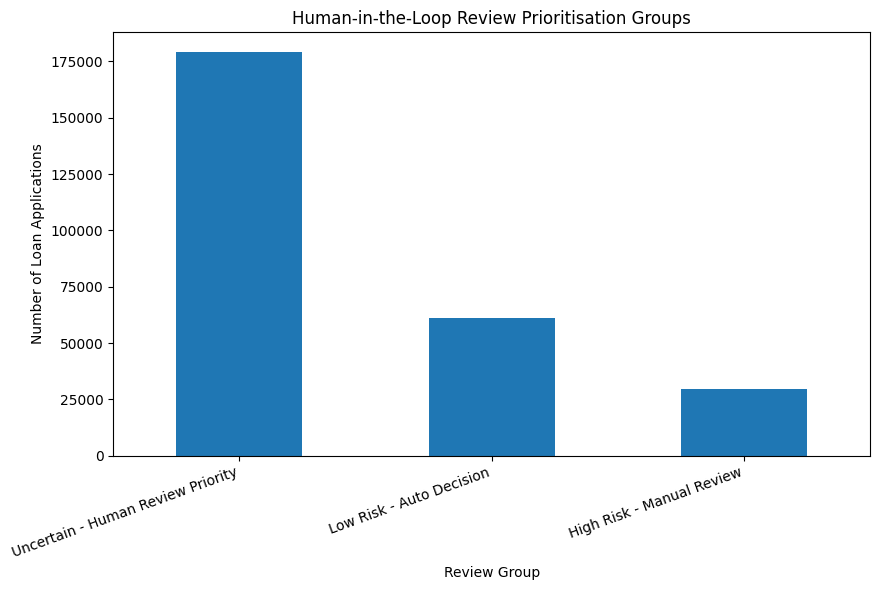

Human review prioritisation figure saved successfully
File saved at: /kaggle/working/human_review_prioritisation_figure.pdf


In [24]:
import matplotlib.pyplot as plt

# Create human review prioritisation figure

review_group_counts = review_results["review_group"].value_counts()

plt.figure(figsize=(9, 6))
review_group_counts.plot(kind="bar")

plt.xlabel("Review Group")
plt.ylabel("Number of Loan Applications")
plt.title("Human-in-the-Loop Review Prioritisation Groups")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.savefig("/kaggle/working/human_review_prioritisation_figure.pdf", format="pdf", bbox_inches="tight")
plt.show()

print("Human review prioritisation figure saved successfully")
print("File saved at: /kaggle/working/human_review_prioritisation_figure.pdf")

In [25]:
import os

output_files = os.listdir("/kaggle/working")

print("Files saved in /kaggle/working:")
for file in output_files:
    print(file)

Files saved in /kaggle/working:
model_comparison_results.csv
confusion_matrix_best_model.pdf
human_review_prioritisation_results.csv
model_comparison_figure.pdf
roc_curve_comparison.pdf
.virtual_documents
human_review_prioritisation_figure.pdf
missing_data_analysis.pdf
